In [1]:
!pip install torch torchvision scikit-learn matplotlib seaborn

In [5]:
import os, random, copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_score, recall_score, f1_score)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)
print('Libraries loaded!')


Using device: cpu
Libraries loaded!


In [6]:
BASE       = os.getcwd()
TRAIN_PATH = os.path.join(BASE, 'archive_extracted', 'Training')
TEST_PATH  = os.path.join(BASE, 'archive_extracted', 'Testing')

print('Training folder:', TRAIN_PATH)
print('Testing  folder:', TEST_PATH)
print('Train exists:', os.path.exists(TRAIN_PATH))
print('Test  exists:', os.path.exists(TEST_PATH))

IMG_SIZE    = 128
BATCH_SIZE  = 32
NUM_CLASSES = 4
EPOCHS      = 15
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']


Training folder: C:\Users\ARCHANA\computervision_cw\archive_extracted\Training
Testing  folder: C:\Users\ARCHANA\computervision_cw\archive_extracted\Testing
Train exists: True
Test  exists: True


In [9]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)
test_dataset  = datasets.ImageFolder(TEST_PATH,  transform=test_transform)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print('Classes:', train_dataset.classes)
print(f'Train: {len(train_dataset)} images  |  Test: {len(test_dataset)} images')


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train: 5600 images  |  Test: 1600 images


In [11]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct = 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds       = outputs.argmax(1)
            correct    += (preds == labels).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / len(loader.dataset), correct / len(loader.dataset), all_preds, all_labels


def train_model(model, train_loader, test_loader, epochs, lr, name):
    model     = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history  = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0.0
    best_wts = copy.deepcopy(model.state_dict())

    print(f'\n--- Training: {name} ---')
    for epoch in range(1, epochs + 1):
        t_loss, t_acc        = train_one_epoch(model, train_loader, criterion, optimizer)
        v_loss, v_acc, _, _  = evaluate(model, test_loader, criterion)
        scheduler.step()

        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)

        if v_acc > best_acc:
            best_acc = v_acc
            best_wts = copy.deepcopy(model.state_dict())

        print(f'  Epoch {epoch:02d}/{epochs}  '
              f'Train Loss: {t_loss:.4f}  Train Acc: {t_acc:.4f}  '
              f'Val Loss: {v_loss:.4f}  Val Acc: {v_acc:.4f}')

    model.load_state_dict(best_wts)
    print(f'✅ Best Val Accuracy: {best_acc:.4f}')
    return model, history


print('Helper functions ready!')


Helper functions ready!


In [13]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.1),      # 128 → 64
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),      # 64 → 32
            # Block 3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.3),      # 32 → 16
            # Block 4
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),                          # 16 → 8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 4),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


print(ImprovedCNN())


ImprovedCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout2d(p=0.2, i

In [15]:
model2, history = train_model(
    model        = ImprovedCNN(),
    train_loader = train_loader,
    test_loader  = test_loader,
    epochs       = 20,
    lr           = 0.0005,
    name         = 'Improved CNN'
)

torch.save(model2.state_dict(), 'model2_improved.pth')
print('Model 2 saved!')



--- Training: Improved CNN ---
  Epoch 01/20  Train Loss: 1.2519  Train Acc: 0.5750  Val Loss: 1.0006  Val Acc: 0.6669
  Epoch 02/20  Train Loss: 0.6745  Train Acc: 0.7414  Val Loss: 0.7899  Val Acc: 0.7262
  Epoch 03/20  Train Loss: 0.5918  Train Acc: 0.7630  Val Loss: 0.7593  Val Acc: 0.7344
  Epoch 04/20  Train Loss: 0.5351  Train Acc: 0.7857  Val Loss: 0.7536  Val Acc: 0.7356
  Epoch 05/20  Train Loss: 0.4882  Train Acc: 0.7986  Val Loss: 0.7362  Val Acc: 0.7913
  Epoch 06/20  Train Loss: 0.4072  Train Acc: 0.8395  Val Loss: 0.7457  Val Acc: 0.8113
  Epoch 07/20  Train Loss: 0.3740  Train Acc: 0.8559  Val Loss: 0.8007  Val Acc: 0.8400
  Epoch 08/20  Train Loss: 0.3639  Train Acc: 0.8571  Val Loss: 0.7360  Val Acc: 0.8263
  Epoch 09/20  Train Loss: 0.3354  Train Acc: 0.8666  Val Loss: 0.7091  Val Acc: 0.8294
  Epoch 10/20  Train Loss: 0.3221  Train Acc: 0.8789  Val Loss: 0.8008  Val Acc: 0.8369
  Epoch 11/20  Train Loss: 0.2868  Train Acc: 0.8943  Val Loss: 0.7539  Val Acc: 0.8519


In [17]:
criterion = nn.CrossEntropyLoss()
_, acc, preds, labels = evaluate(model2, test_loader, criterion)

print(f'Test Accuracy : {acc:.4f}')
prec = precision_score(labels, preds, average='weighted', zero_division=0)
rec  = recall_score(   labels, preds, average='weighted', zero_division=0)
f1   = f1_score(       labels, preds, average='weighted', zero_division=0)
print(f'Precision     : {prec:.4f}')
print(f'Recall        : {rec:.4f}')
print(f'F1 Score      : {f1:.4f}')


Test Accuracy : 0.8819
Precision     : 0.8873
Recall        : 0.8819
F1 Score      : 0.8785


In [22]:
!pip install seaborn
import sys
!{sys.executable} -m pip install seaborn
import seaborn as sns

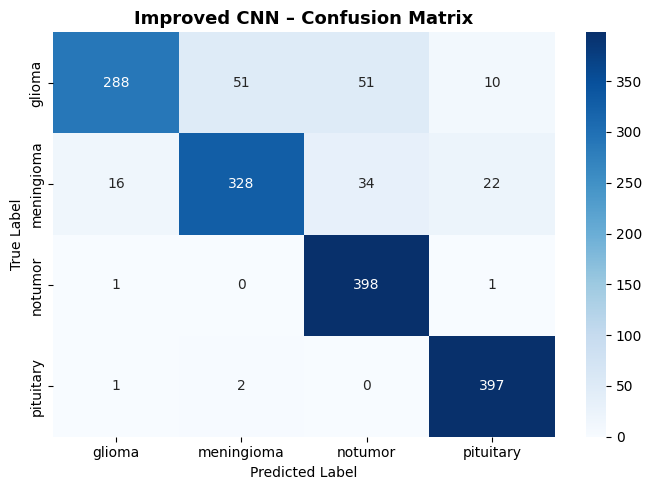

Saved: model2_confusion_matrix.png


In [24]:
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Improved CNN – Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('model2_confusion_matrix.png')
plt.show()
print('Saved: model2_confusion_matrix.png')


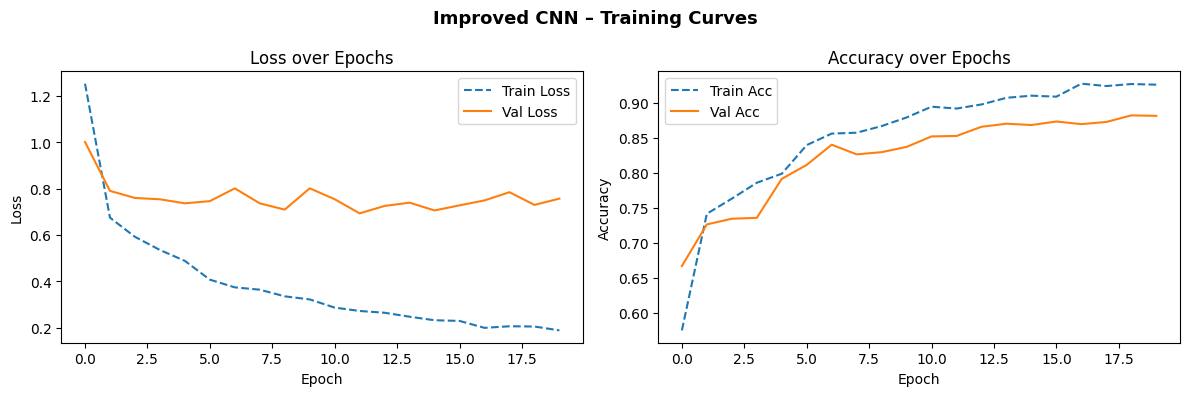

Saved: model2_training_curves.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], '--', label='Train Loss')
axes[0].plot(history['val_loss'],   '-',  label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history['train_acc'], '--', label='Train Acc')
axes[1].plot(history['val_acc'],   '-',  label='Val Acc')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Improved CNN – Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model2_training_curves.png')
plt.show()
print('Saved: model2_training_curves.png')


In [28]:
print(classification_report(labels, preds, target_names=CLASS_NAMES))


              precision    recall  f1-score   support

      glioma       0.94      0.72      0.82       400
  meningioma       0.86      0.82      0.84       400
     notumor       0.82      0.99      0.90       400
   pituitary       0.92      0.99      0.96       400

    accuracy                           0.88      1600
   macro avg       0.89      0.88      0.88      1600
weighted avg       0.89      0.88      0.88      1600

